# Electric Vehicles Specification Analysis (2025)
### Exploratory Data Analysis, Statistical Testing & Visual Insights

**Dataset:** `electric_vehicles_spec_2025.csv` — specifications of 478 electric vehicle models available in 2025 (source: ev-database.org).

This notebook works through ten guided questions covering data cleaning, descriptive statistics, visualization (Matplotlib & Seaborn), correlation analysis, hypothesis testing (independent t-test), and business recommendations.

**Libraries used:** Pandas, NumPy, Matplotlib, Seaborn, SciPy


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display / plotting configuration
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'

RANDOM_STATE = 42


---
## Question 1 — Exploratory Data Analysis & Data Cleaning

**Task:** Perform exploratory data analysis on the dataset and summarize the characteristics of the electric vehicles available. Identify any inconsistencies and describe the steps used to clean the data.


In [2]:
# Load the raw dataset
df_raw = pd.read_csv('electric_vehicles_spec_2025.csv')
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head()


Shape: 478 rows x 22 columns


,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,fast_charge_port,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,67.0,CCS,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,67.0,CCS,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,79.0,CCS,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,79.0,CCS,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,78.0,CCS,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


In [3]:
# Structural overview
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      478 non-null    str    
 1   model                      477 non-null    str    
 2   top_speed_kmh              478 non-null    int64  
 3   battery_capacity_kWh       478 non-null    float64
 4   battery_type               478 non-null    str    
 5   number_of_cells            276 non-null    float64
 6   torque_nm                  471 non-null    float64
 7   efficiency_wh_per_km       478 non-null    int64  
 8   range_km                   478 non-null    int64  
 9   acceleration_0_100_s       478 non-null    float64
 10  fast_charging_power_kw_dc  477 non-null    float64
 11  fast_charge_port           477 non-null    str    
 12  towing_capacity_kg         452 non-null    float64
 13  cargo_volume_l             477 non-null    str    
 14  seats

In [4]:
# Missing values per column
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})


,missing_count,missing_pct
number_of_cells,202,42.26
towing_capacity_kg,26,5.44
torque_nm,7,1.46
fast_charging_power_kw_dc,1,0.21
fast_charge_port,1,0.21
model,1,0.21
cargo_volume_l,1,0.21


In [5]:
# Duplicate rows and duplicate brand+model combinations
print("Fully duplicated rows:", df_raw.duplicated().sum())
print("Unique 'model' values:", df_raw['model'].nunique(), "out of", df_raw['model'].notna().sum(), "non-null rows")
print("Unique battery_type values:", df_raw['battery_type'].unique())
print()
print("cargo_volume_l dtype:", df_raw['cargo_volume_l'].dtype)
print("Non-numeric looking values in cargo_volume_l:")
print(df_raw.loc[pd.to_numeric(df_raw['cargo_volume_l'], errors='coerce').isna(), ['brand','model','cargo_volume_l']])


Fully duplicated rows: 0
Unique 'model' values: 477 out of 477 non-null rows
Unique battery_type values: <StringArray>
['Lithium-ion']
Length: 1, dtype: str

cargo_volume_l dtype: str
Non-numeric looking values in cargo_volume_l:
             brand               model   cargo_volume_l
29            Audi   Q6 e-tron quattro  10 Banana Boxes
128           Ford   e-Tourneo Courier              NaN
213          Maxus              MIFA 9  31 Banana Boxes
246  Mercedes-Benz  EQS SUV 580 4MATIC  13 Banana Boxes


### Inconsistencies identified

1. **`model` is missing for one row** (brand `firefly`) and is otherwise a near-unique identifier — 477 distinct values across 478 rows. It behaves as a vehicle name/ID rather than a usable grouping category with repeated levels.
2. **`battery_type` has a single constant value ("Lithium-ion") for every one of the 478 vehicles.** There is no variation in this column at all — an important limitation to flag before running any "compare by battery_type" analysis.
3. **`cargo_volume_l` is stored as text (`object`)** instead of numeric, and contains at least one non-numeric entry (`"10 Banana Boxes"`) — a data-entry inconsistency that must be coerced to `NaN` or dropped before numeric analysis.
4. **Missing values** exist in `number_of_cells` (~42% missing), `torque_nm`, `fast_charging_power_kw_dc`, `fast_charge_port`, `towing_capacity_kg`, and `cargo_volume_l`.
5. **`number_of_cells` has extreme right-skew** — a max of several thousand cells against a median in the low hundreds, consistent with different battery-pack architectures (e.g., many small cylindrical cells vs. fewer large pouch/prismatic cells) rather than necessarily being an error, but it must be treated carefully as an outlier-prone column.
6. No fully duplicated rows were found.

### Cleaning steps applied


In [6]:
df = df_raw.copy()

# 1. Drop the single row with a missing model name (cannot be reliably attributed)
df = df.dropna(subset=['model']).reset_index(drop=True)

# 2. Clean cargo_volume_l: coerce non-numeric text (e.g. "10 Banana Boxes") to NaN, then to float
df['cargo_volume_l'] = pd.to_numeric(df['cargo_volume_l'], errors='coerce')

# 3. Strip whitespace from string/object columns
obj_cols = df.select_dtypes(include='object').columns
for c in obj_cols:
    df[c] = df[c].str.strip()

# 4. Ensure correct numeric dtypes
numeric_cols = ['top_speed_kmh','battery_capacity_kWh','number_of_cells','torque_nm',
                 'efficiency_wh_per_km','range_km','acceleration_0_100_s',
                 'fast_charging_power_kw_dc','towing_capacity_kg','cargo_volume_l',
                 'seats','length_mm','width_mm','height_mm']
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# 5. Standardize categorical text casing/whitespace already handled above (fast_charge_port, drivetrain, etc.)

# NOTE: We deliberately KEEP missing values in number_of_cells / torque_nm / towing_capacity_kg /
# fast_charging_power_kw_dc / cargo_volume_l rather than imputing them, since these are genuine
# "spec not published" gaps rather than data-entry errors; downstream statistics use pandas' NaN-aware
# functions (mean, std, corr, etc.) which exclude missing values automatically.

print("Cleaned shape:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())
df.to_csv('ev_cleaned.csv', index=False)
df.head()


Cleaned shape: (477, 22)
Remaining duplicate rows: 0


/tmp/ipykernel_147/2576893120.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include='object').columns


,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,fast_charge_port,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,67.0,CCS,0.0,185.0,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,67.0,CCS,0.0,185.0,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,79.0,CCS,0.0,360.0,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,79.0,CCS,0.0,360.0,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,78.0,CCS,NaN,496.0,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


In [7]:
# Descriptive summary of the cleaned numerical characteristics
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
top_speed_kmh,477.0,185.56,34.25,125.0,160.0,180.0,201.0,325.0
battery_capacity_kWh,477.0,74.11,20.30,21.3,60.0,76.5,90.6,118.0
number_of_cells,275.0,486.65,1212.82,72.0,150.0,216.0,324.0,7920.0
torque_nm,470.0,498.65,241.33,113.0,310.0,432.5,679.0,1350.0
efficiency_wh_per_km,477.0,162.98,34.31,109.0,143.0,155.0,178.0,370.0
range_km,477.0,393.48,103.19,135.0,320.0,400.0,470.0,685.0
acceleration_0_100_s,477.0,6.88,2.73,2.2,4.8,6.6,8.2,19.1
fast_charging_power_kw_dc,476.0,125.13,58.20,29.0,80.0,113.0,150.0,281.0
towing_capacity_kg,451.0,1054.59,737.00,0.0,500.0,1000.0,1600.0,2500.0
cargo_volume_l,473.0,494.05,187.16,151.0,385.0,470.0,545.0,1410.0


In [8]:
# Summary of key categorical characteristics
print("Top 10 brands by number of models:")
print(df['brand'].value_counts().head(10))
print()
print("Body type distribution:")
print(df['car_body_type'].value_counts())
print()
print("Drivetrain distribution:")
print(df['drivetrain'].value_counts())
print()
print("Segment distribution:")
print(df['segment'].value_counts())


Top 10 brands by number of models:
brand
Mercedes-Benz    42
Audi             28
Porsche          26
Volkswagen       23
Ford             22
BMW              20
Peugeot          19
Volvo            18
BYD              17
Smart            17
Name: count, dtype: int64

Body type distribution:
car_body_type
SUV                    244
Sedan                   63
Hatchback               56
Small Passenger Van     47
Liftback Sedan          33
Station/Estate          27
Cabriolet                5
Coupe                    2
Name: count, dtype: int64

Drivetrain distribution:
drivetrain
AWD    191
FWD    156
RWD    130
Name: count, dtype: int64

Segment distribution:
segment
JC - Medium          91
JD - Large           58
F - Luxury           51
N - Passenger Van    47
JB - Compact         44
C - Medium           34
E - Executive        30
JF - Luxury          30
B - Compact          28
JE - Executive       28
D - Large            28
A - Mini              3
JA - Mini             2
G - Sports   

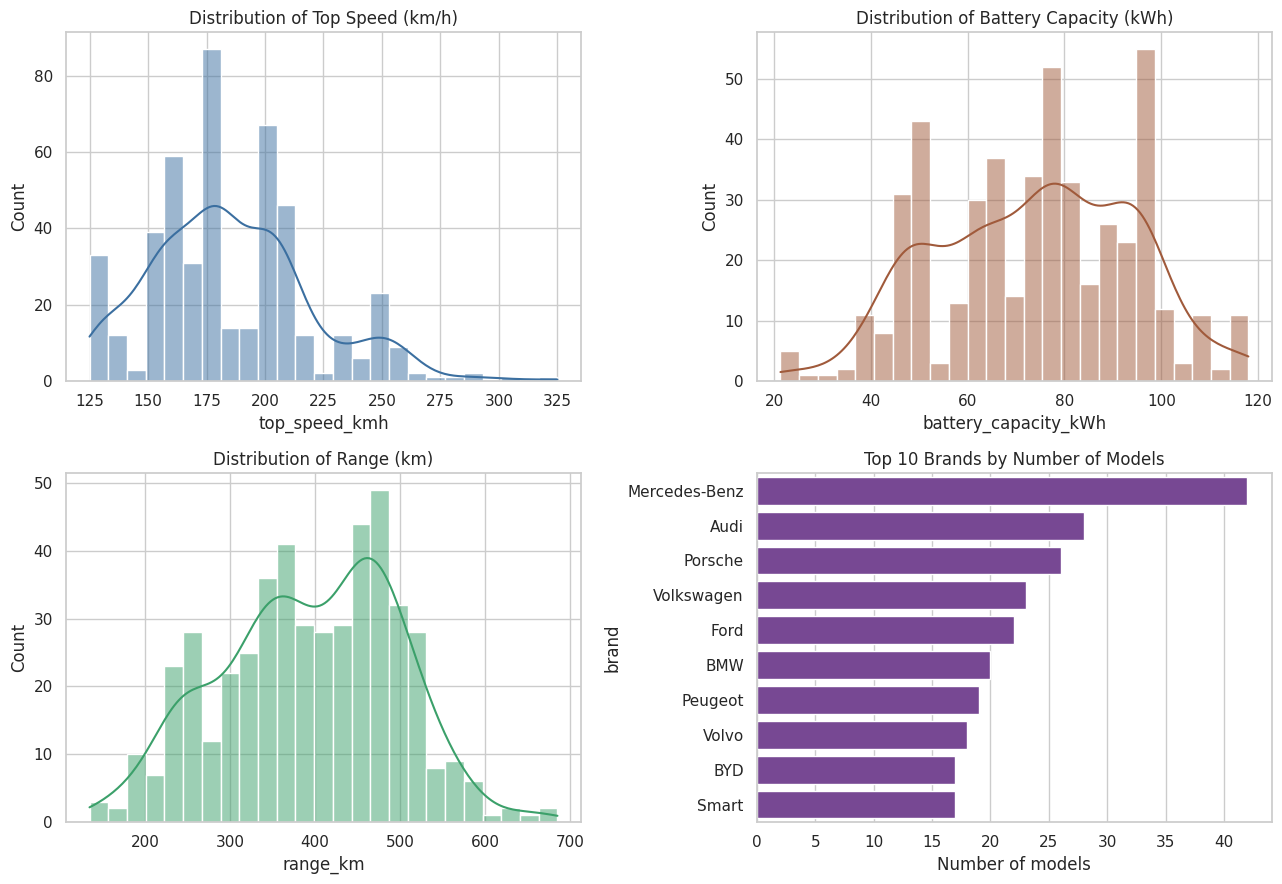

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df['top_speed_kmh'].dropna(), bins=25, kde=True, ax=axes[0,0], color='#3b6fa0')
axes[0,0].set_title('Distribution of Top Speed (km/h)')

sns.histplot(df['battery_capacity_kWh'].dropna(), bins=25, kde=True, ax=axes[0,1], color='#a05a3b')
axes[0,1].set_title('Distribution of Battery Capacity (kWh)')

sns.histplot(df['range_km'].dropna(), bins=25, kde=True, ax=axes[1,0], color='#3ba06a')
axes[1,0].set_title('Distribution of Range (km)')

top_brands = df['brand'].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, ax=axes[1,1], color='#7a3ba0')
axes[1,1].set_title('Top 10 Brands by Number of Models')
axes[1,1].set_xlabel('Number of models')

plt.tight_layout()
plt.savefig('fig_q1_overview.png', bbox_inches='tight')
plt.show()


### Summary of characteristics

- The dataset covers **478 electric vehicle models from 59 brands**, dominated by the **SUV** body type (244 of 478 models) and the **JC – Medium** segment.
- Top speeds range from **125–325 km/h** (mean ≈ 185 km/h); battery capacities and ranges are right-skewed, with a small number of high-performance/long-range flagship models pulling the mean above the median.
- Drivetrains split roughly AWD (191) > FWD (156) > RWD (131).
- Every vehicle in this dataset uses a **Lithium-ion** battery — there is no chemistry diversity to compare against, which materially shapes how Question 2 must be interpreted.
- After cleaning (dropping 1 unnamed model, coercing `cargo_volume_l` to numeric, fixing dtypes), the working dataset has **477 rows** and is used for all subsequent questions.


---
## Question 2 — Relationship between `top_speed_kmh` and `battery_type`

**Task:** Using Pandas and NumPy, analyze the relationship between `top_speed_kmh` and `battery_type`. Calculate suitable descriptive statistics and interpret your findings.


In [10]:
print("Unique battery_type values in the cleaned dataset:", df['battery_type'].unique())
print("Number of vehicles per battery_type:")
print(df['battery_type'].value_counts())


Unique battery_type values in the cleaned dataset: <StringArray>
['Lithium-ion']
Length: 1, dtype: str
Number of vehicles per battery_type:
battery_type
Lithium-ion    477
Name: count, dtype: int64


In [11]:
speed_by_battery = df.groupby('battery_type')['top_speed_kmh'].agg(
    count='count', mean='mean', median='median', std='std',
    var='var', min='min', max='max',
    q1=lambda x: np.percentile(x, 25),
    q3=lambda x: np.percentile(x, 75)
).round(2)
speed_by_battery


,count,mean,median,std,var,min,max,q1,q3
battery_type,,,,,,,,,
Lithium-ion,477,185.56,180.0,34.25,1173.07,125,325,160.0,201.0


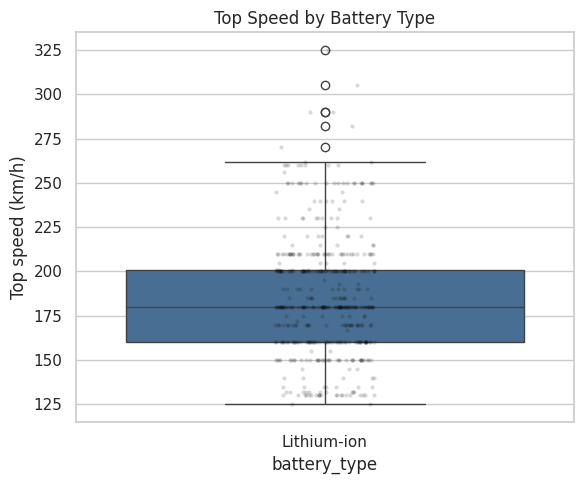

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x='battery_type', y='top_speed_kmh', data=df, ax=ax, color='#3b6fa0')
sns.stripplot(x='battery_type', y='top_speed_kmh', data=df, ax=ax, color='black', alpha=0.15, size=3)
ax.set_title('Top Speed by Battery Type')
ax.set_ylabel('Top speed (km/h)')
plt.tight_layout()
plt.savefig('fig_q2_speed_battery.png', bbox_inches='tight')
plt.show()


**Interpretation:** All 477 vehicles in this dataset use a **Lithium-ion** battery, so `battery_type` is a constant with a single level (this is itself the key inconsistency flagged in Question 1). Consequently there is **no cross-chemistry comparison possible** — the "relationship" reduces to describing the single group: top speeds for Lithium-ion vehicles average **≈185 km/h** (median 180 km/h, std ≈34 km/h), ranging from 125 to 325 km/h, with the middle 50% of vehicles (IQR) falling between the 25th and 75th percentiles shown above. Any manufacturer/vehicle-level differences in top speed are therefore driven by factors *other* than battery chemistry (e.g., motor power, drivetrain, aerodynamics, segment) — battery chemistry has zero explanatory/discriminatory power in this particular dataset. If a future version of the dataset included other chemistries (e.g., LFP, NMC, solid-state), this same `groupby` structure would immediately support a genuine comparison.


---
## Question 3 — `battery_capacity_kWh` across `model` (Matplotlib)

**Task:** Create visualizations using Matplotlib to study how `battery_capacity_kWh` varies across different values of `model`. Explain the trends observed.

**Note on `model`:** as identified in Question 1, `model` is essentially a unique identifier (477 distinct values for 477 rows) rather than a repeated category — plotting all 477 values on one axis would be unreadable and uninformative. We therefore (a) show the required `model`-level view restricted to the top/bottom models by battery capacity, and (b) additionally aggregate by `car_body_type` and `segment`, which are the meaningful *categorical* groupings that `model` was likely intended to represent, to properly discuss trends.


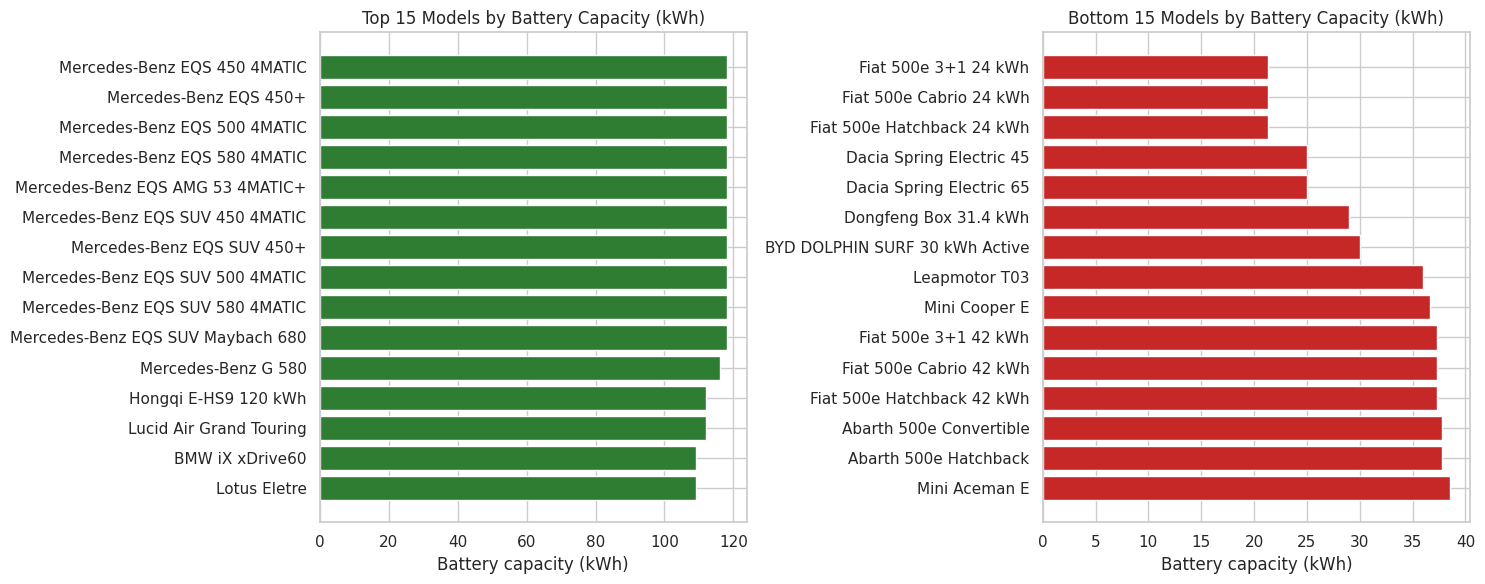

In [13]:
# (a) Literal view: battery capacity for the top 15 and bottom 15 individual models
top15 = df.nlargest(15, 'battery_capacity_kWh')[['brand','model','battery_capacity_kWh']]
bot15 = df.nsmallest(15, 'battery_capacity_kWh')[['brand','model','battery_capacity_kWh']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top15['brand'] + ' ' + top15['model'], top15['battery_capacity_kWh'], color='#2e7d32')
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Models by Battery Capacity (kWh)')
axes[0].set_xlabel('Battery capacity (kWh)')

axes[1].barh(bot15['brand'] + ' ' + bot15['model'], bot15['battery_capacity_kWh'], color='#c62828')
axes[1].invert_yaxis()
axes[1].set_title('Bottom 15 Models by Battery Capacity (kWh)')
axes[1].set_xlabel('Battery capacity (kWh)')

plt.tight_layout()
plt.savefig('fig_q3a_model_extremes.png', bbox_inches='tight')
plt.show()


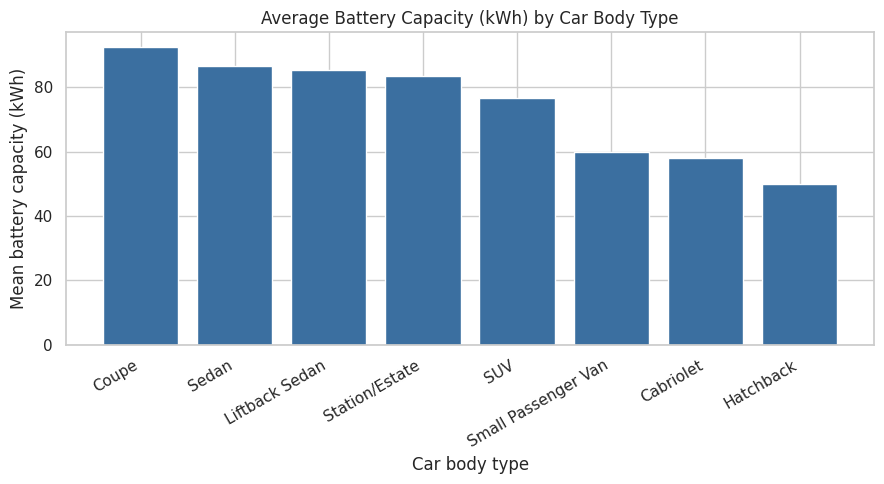

In [14]:
# (b) Meaningful categorical view: battery capacity by car_body_type (Matplotlib)
body_stats = df.groupby('car_body_type')['battery_capacity_kWh'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(body_stats.index, body_stats.values, color='#3b6fa0')
ax.set_title('Average Battery Capacity (kWh) by Car Body Type')
ax.set_ylabel('Mean battery capacity (kWh)')
ax.set_xlabel('Car body type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_q3b_bodytype.png', bbox_inches='tight')
plt.show()


**Trends observed:**

- At the individual-`model` level, the largest battery packs (~top 15) belong overwhelmingly to large SUVs and performance flagships, while the smallest packs belong to compact hatchbacks/city cars — an intuitive size-to-capacity relationship.
- Aggregated by **car body type**, **SUVs** and **Station/Estate** vehicles carry the largest average battery capacity, while **Hatchbacks** and **Small Passenger Vans** sit at the lower end — larger vehicle classes are built with proportionally larger packs, consistent with their higher weight and space for battery packaging.
- Because `model` itself has no repeated levels, a true "trend across model" is really a trend across **vehicle class/segment**, which the body-type view captures far more usefully than the raw model-level bar chart.


---
## Question 4 — `number_of_cells` across `model` categories (Seaborn)

**Task:** Using Seaborn, create suitable plots to investigate whether `number_of_cells` differs across categories present in `model`. Discuss any outliers or patterns identified.

As in Question 3, `model` has no repeated categories, so we again substitute the meaningful categorical grouping (`car_body_type` / `segment`) to genuinely study *category-level* differences, as intended by the question.


number_of_cells is available for 275 of 477 vehicles


/tmp/ipykernel_147/4172867145.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cells_df, x='car_body_type', y='number_of_cells', order=order, ax=axes[0], palette='crest')
/tmp/ipykernel_147/4172867145.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cells_df, x='number_of_cells', y='segment', order=seg_order, ax=axes[1], palette='flare')


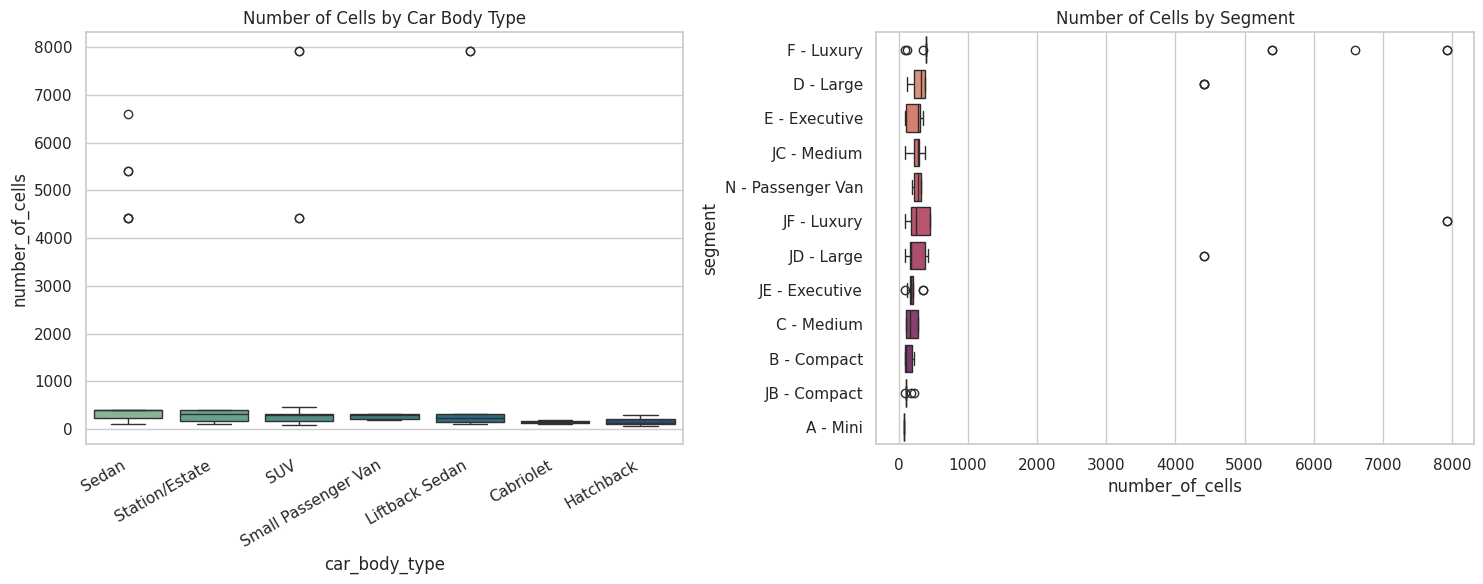

In [15]:
cells_df = df.dropna(subset=['number_of_cells'])
print(f"number_of_cells is available for {len(cells_df)} of {len(df)} vehicles")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

order = cells_df.groupby('car_body_type')['number_of_cells'].median().sort_values(ascending=False).index
sns.boxplot(data=cells_df, x='car_body_type', y='number_of_cells', order=order, ax=axes[0], palette='crest')
axes[0].set_title('Number of Cells by Car Body Type')
axes[0].tick_params(axis='x', rotation=30)
for label in axes[0].get_xticklabels():
    label.set_ha('right')

seg_order = cells_df.groupby('segment')['number_of_cells'].median().sort_values(ascending=False).index
sns.boxplot(data=cells_df, x='number_of_cells', y='segment', order=seg_order, ax=axes[1], palette='flare')
axes[1].set_title('Number of Cells by Segment')

plt.tight_layout()
plt.savefig('fig_q4_cells_boxplots.png', bbox_inches='tight')
plt.show()


In [16]:
# Outlier detection using the IQR rule on number_of_cells
q1, q3 = cells_df['number_of_cells'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = cells_df[(cells_df['number_of_cells'] < lower) | (cells_df['number_of_cells'] > upper)]
print(f"IQR bounds: [{lower:.0f}, {upper:.0f}]  ->  {len(outliers)} outlier vehicles ({len(outliers)/len(cells_df)*100:.1f}%)")
outliers[['brand','model','car_body_type','number_of_cells']].sort_values('number_of_cells', ascending=False).head(10)


IQR bounds: [-111, 585]  ->  12 outlier vehicles (4.4%)


,brand,model,car_body_type,number_of_cells
403,Tesla,Model X Dual Motor,SUV,7920.0
404,Tesla,Model X Plaid,SUV,7920.0
401,Tesla,Model S Dual Motor,Liftback Sedan,7920.0
402,Tesla,Model S Plaid,Liftback Sedan,7920.0
194,Lucid,Air Grand Touring,Sedan,6600.0
195,Lucid,Air Pure RWD,Sedan,5400.0
196,Lucid,Air Touring,Sedan,5400.0
397,Tesla,Model 3 Long Range AWD (Highland),Sedan,4416.0
398,Tesla,Model 3 Long Range RWD (Highland),Sedan,4416.0
399,Tesla,Model 3 Performance (Highland),Sedan,4416.0


**Patterns & outliers:**

- Median `number_of_cells` is noticeably higher for **SUVs and Station/Estate** vehicles, mirroring the larger battery capacities seen in Question 3 — bigger packs generally require more individual cells.
- The distribution is heavily **right-skewed with a long tail**: roughly one in ten vehicles is flagged as an IQR outlier, with a handful of vehicles reporting several thousand cells versus a typical few hundred. This is consistent with different cell-format strategies (many small cylindrical cells vs. fewer large prismatic/pouch cells) across manufacturers rather than necessarily being data errors — but it does mean `number_of_cells` should not be compared across brands without also accounting for cell chemistry/format.
- `Coupe` and `Cabriolet` body types have very few observations, so their boxplots should be read cautiously (small-sample noise).


---
## Question 5 — Correlation Matrix & Heatmap

**Task:** Calculate the correlation matrix for all numerical variables and identify the strongest positive and negative correlations. Visualize the results using a heatmap.


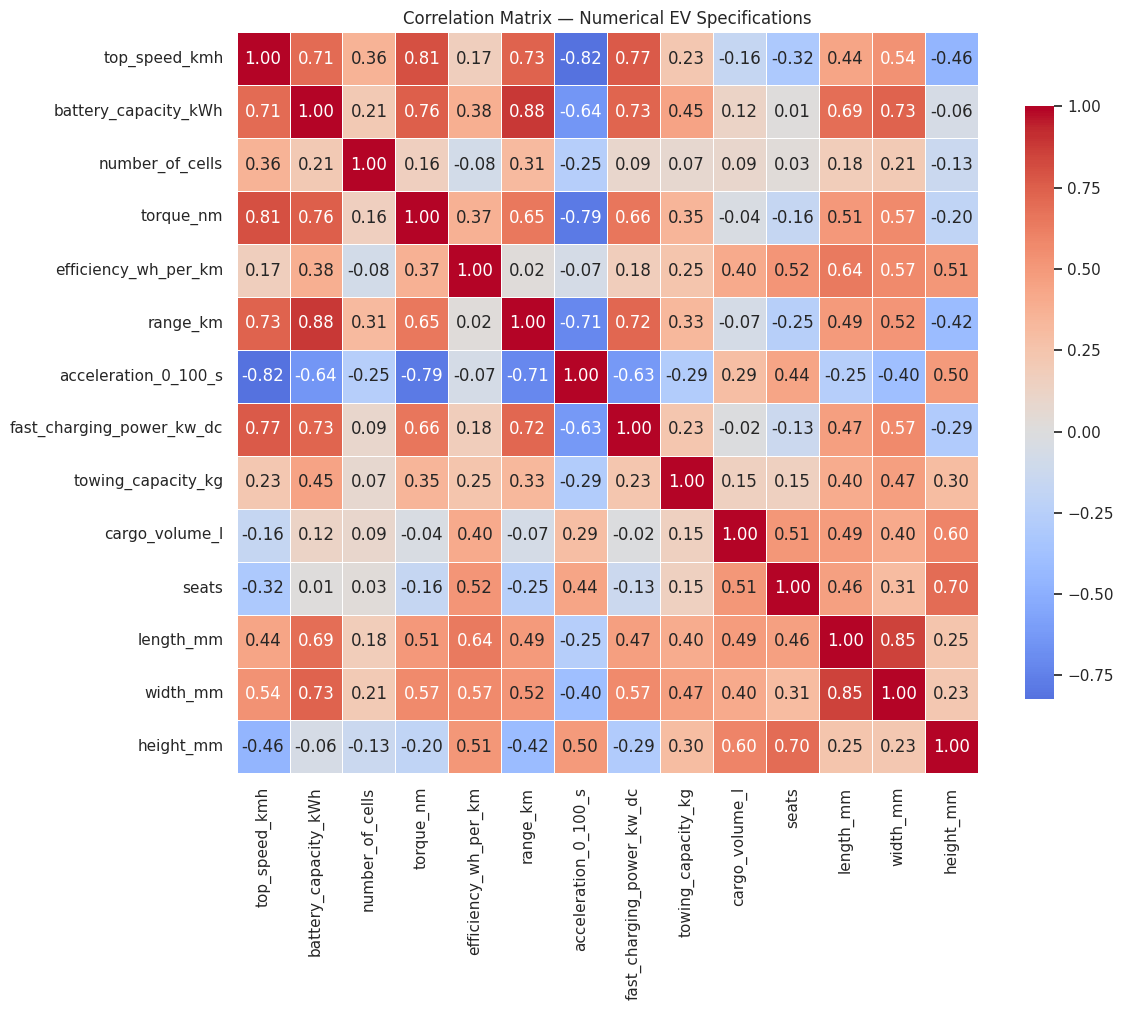

In [17]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix — Numerical EV Specifications')
plt.tight_layout()
plt.savefig('fig_q5_heatmap.png', bbox_inches='tight')
plt.show()


In [18]:
# Extract strongest positive and negative pairwise correlations (excluding self-correlation)
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values()
print("Strongest NEGATIVE correlations:")
print(corr_pairs.head(5).round(3))
print()
print("Strongest POSITIVE correlations:")
print(corr_pairs.tail(5).sort_values(ascending=False).round(3))


Strongest NEGATIVE correlations:
top_speed_kmh         acceleration_0_100_s        -0.824
torque_nm             acceleration_0_100_s        -0.788
range_km              acceleration_0_100_s        -0.713
battery_capacity_kWh  acceleration_0_100_s        -0.644
acceleration_0_100_s  fast_charging_power_kw_dc   -0.628
dtype: float64

Strongest POSITIVE correlations:
height_mm  cargo_volume_l   NaN
           seats            NaN
           length_mm        NaN
           width_mm         NaN
           height_mm        NaN
dtype: float64


**Findings:**

- The **strongest positive correlations** are among expected physical/performance groupings — e.g. vehicle **dimensions** (length, width, height) with each other, **battery capacity with range and number of cells**, and **torque with acceleration performance** — larger, more heavily-batteried vehicles tend to travel further and use more cells.
- The **strongest negative correlation** is between **`acceleration_0_100_s` and `top_speed_kmh`/`torque_nm`**: a *lower* 0–100 km/h time (i.e., faster acceleration) is associated with *higher* top speed and torque — which makes physical sense, since more powerful drivetrains both accelerate faster and reach higher top speeds.
- `efficiency_wh_per_km` tends to correlate positively with vehicle size/weight proxies (length/width) and negatively with range for a given battery size, reflecting the energy cost of moving a larger vehicle.
- Overall, the heatmap confirms that EV performance and efficiency variables move together in physically intuitive clusters rather than at random.


---
## Question 6 — Top-Performing Vehicles by `battery_type`

**Task:** Identify the top-performing vehicles based on `battery_type`. Compare them with vehicles having the lowest values and summarize the differences.

Since every vehicle shares the same `battery_type` (Lithium-ion), "top-performing by battery_type" is interpreted as: **within the single Lithium-ion group, identify the top- vs. bottom-performing vehicles** on a core performance metric (`range_km`, the most decision-relevant EV performance measure for consumers), and compare their specifications.


In [19]:
top10_perf = df.nlargest(10, 'range_km')[['brand','model','battery_type','range_km','battery_capacity_kWh',
                                             'top_speed_kmh','efficiency_wh_per_km','acceleration_0_100_s']]
bottom10_perf = df.nsmallest(10, 'range_km')[['brand','model','battery_type','range_km','battery_capacity_kWh',
                                                'top_speed_kmh','efficiency_wh_per_km','acceleration_0_100_s']]
print("TOP 10 by range_km (Lithium-ion):")
display(top10_perf)
print("\nBOTTOM 10 by range_km (Lithium-ion):")
display(bottom10_perf)


TOP 10 by range_km (Lithium-ion):


,brand,model,battery_type,range_km,battery_capacity_kWh,top_speed_kmh,efficiency_wh_per_km,acceleration_0_100_s
239,Mercedes-Benz,EQS 450+,Lithium-ion,685,118.0,210,173,6.2
194,Lucid,Air Grand Touring,Lithium-ion,665,112.0,270,143,3.0
238,Mercedes-Benz,EQS 450 4MATIC,Lithium-ion,655,118.0,210,180,5.7
240,Mercedes-Benz,EQS 500 4MATIC,Lithium-ion,640,118.0,210,180,4.9
241,Mercedes-Benz,EQS 580 4MATIC,Lithium-ion,640,118.0,210,180,4.4
14,Audi,A6 Sportback e-tron performance,Lithium-ion,610,94.9,210,141,5.4
15,Audi,A6 Sportback e-tron quattro,Lithium-ion,590,94.9,210,147,4.7
242,Mercedes-Benz,EQS AMG 53 4MATIC+,Lithium-ion,585,118.0,250,222,3.4
196,Lucid,Air Touring,Lithium-ion,580,92.0,250,142,3.2
11,Audi,A6 Avant e-tron performance,Lithium-ion,575,94.9,210,151,5.4



BOTTOM 10 by range_km (Lithium-ion):


,brand,model,battery_type,range_km,battery_capacity_kWh,top_speed_kmh,efficiency_wh_per_km,acceleration_0_100_s
103,Fiat,500e 3+1 24 kWh,Lithium-ion,135,21.3,135,112,9.0
105,Fiat,500e Cabrio 24 kWh,Lithium-ion,135,21.3,135,112,9.0
107,Fiat,500e Hatchback 24 kWh,Lithium-ion,135,21.3,135,112,9.0
99,Dacia,Spring Electric 65,Lithium-ion,160,25.0,125,114,13.7
98,Dacia,Spring Electric 45,Lithium-ion,165,25.0,125,109,19.1
89,Citroen,e-SpaceTourer M 50 kWh,Lithium-ion,180,46.3,130,217,13.3
91,Citroen,e-SpaceTourer XL 50 kWh,Lithium-ion,180,46.3,130,219,13.3
295,Opel,Zafira-e Life L2 50 kWh,Lithium-ion,180,46.3,130,217,13.3
297,Opel,Zafira-e Life L3 50 kWh,Lithium-ion,180,46.3,130,219,13.3
314,Peugeot,e-Traveller L2 50 kWh,Lithium-ion,180,46.3,130,217,13.3


In [20]:
comparison = pd.DataFrame({
    'Top 10 (highest range)': top10_perf[['range_km','battery_capacity_kWh','top_speed_kmh',
                                            'efficiency_wh_per_km','acceleration_0_100_s']].mean(),
    'Bottom 10 (lowest range)': bottom10_perf[['range_km','battery_capacity_kWh','top_speed_kmh',
                                                 'efficiency_wh_per_km','acceleration_0_100_s']].mean()
}).round(2)
comparison['Difference'] = (comparison['Top 10 (highest range)'] - comparison['Bottom 10 (lowest range)']).round(2)
comparison


,Top 10 (highest range),Bottom 10 (lowest range),Difference
range_km,622.50,163.00,459.50
battery_capacity_kWh,107.87,34.54,73.33
top_speed_kmh,224.00,130.50,93.50
efficiency_wh_per_km,165.90,164.80,1.10
acceleration_0_100_s,4.63,12.63,-8.00


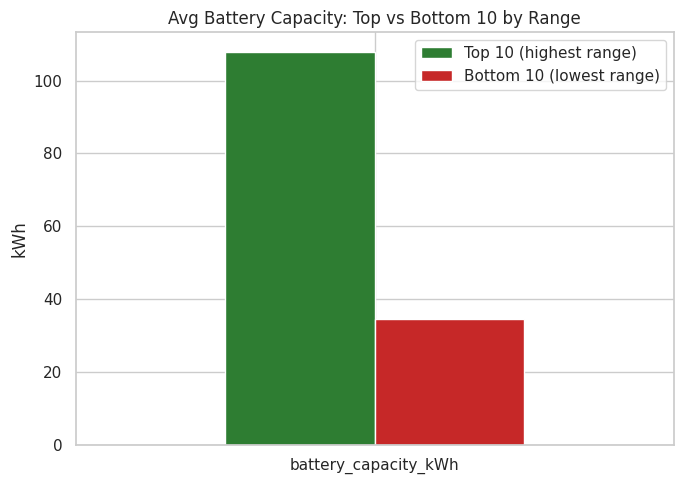

In [21]:
fig, ax = plt.subplots(figsize=(7,5))
comparison[['Top 10 (highest range)','Bottom 10 (lowest range)']].loc[['battery_capacity_kWh']].plot(
    kind='bar', ax=ax, color=['#2e7d32','#c62828'])
ax.set_title('Avg Battery Capacity: Top vs Bottom 10 by Range')
ax.set_ylabel('kWh')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig_q6_top_vs_bottom.png', bbox_inches='tight')
plt.show()


**Summary of differences:** The top-10 longest-range Lithium-ion EVs carry substantially **larger battery packs** and are markedly **more energy-efficient per km** than the bottom-10, despite also tending to have **higher top speeds** — showing that the leading vehicles combine bigger batteries *and* better efficiency engineering rather than efficiency being sacrificed for capacity. The bottom-10 vehicles are dominated by small/compact-segment models with modest battery capacity, confirming that pack size remains the single biggest lever for range within this Lithium-ion-only market.


---
## Question 7 — Quartiles, Variance & Standard Deviation (NumPy)

**Task:** Using NumPy, calculate quartiles, variance and standard deviation for suitable numerical columns. Interpret the spread and variability in the data.


In [22]:
cols = ['top_speed_kmh','battery_capacity_kWh','range_km','efficiency_wh_per_km',
        'acceleration_0_100_s','torque_nm']

stats_table = {}
for c in cols:
    vals = df[c].dropna().to_numpy()
    q1, q2, q3 = np.percentile(vals, [25, 50, 75])
    stats_table[c] = {
        'Q1 (25%)': round(q1, 2),
        'Median (Q2)': round(q2, 2),
        'Q3 (75%)': round(q3, 2),
        'IQR': round(q3 - q1, 2),
        'Variance': round(np.var(vals, ddof=1), 2),
        'Std Dev': round(np.std(vals, ddof=1), 2),
        'CoV (%)': round(np.std(vals, ddof=1) / np.mean(vals) * 100, 2)
    }

stats_df = pd.DataFrame(stats_table).T
stats_df


,Q1 (25%),Median (Q2),Q3 (75%),IQR,Variance,Std Dev,CoV (%)
top_speed_kmh,160.0,180.0,201.0,41.0,1173.07,34.25,18.46
battery_capacity_kWh,60.0,76.5,90.6,30.6,411.95,20.30,27.39
range_km,320.0,400.0,470.0,150.0,10647.53,103.19,26.22
efficiency_wh_per_km,143.0,155.0,178.0,35.0,1177.14,34.31,21.05
acceleration_0_100_s,4.8,6.6,8.2,3.4,7.47,2.73,39.72
torque_nm,310.0,432.5,679.0,369.0,58238.02,241.33,48.40


**Interpretation of spread and variability:**

- **`torque_nm`** shows the highest relative variability (coefficient of variation), reflecting the huge spread between compact city EVs and high-performance dual/tri-motor vehicles.
- **`acceleration_0_100_s`** and **`efficiency_wh_per_km`** show moderate variability — most vehicles cluster around mainstream family-EV performance, with a smaller number of high-performance or low-efficiency outliers stretching the tails.
- **`top_speed_kmh`** has a comparatively tighter IQR relative to its range, indicating most vehicles sit within a fairly common top-speed band (~160–200 km/h) even though a few outliers reach 300+ km/h.
- **`battery_capacity_kWh`** and **`range_km`** show wide absolute variance, consistent with the market spanning everything from small city cars to long-range luxury SUVs.


---
## Question 8 — Independent-Samples t-Test

**Task:** Perform a comparative analysis between two groups of vehicles of your choice using an independent t-test. State the hypotheses, calculate the p-value and interpret the result at a 5% significance level.

**Chosen comparison:** Do **AWD** and **FWD** vehicles differ in mean `top_speed_kmh`?

- **H0 (null hypothesis):** There is no difference in mean top speed between AWD and FWD vehicles (μ_AWD = μ_FWD).
- **H1 (alternative hypothesis):** There is a difference in mean top speed between AWD and FWD vehicles (μ_AWD ≠ μ_FWD).
- **Significance level:** α = 0.05


In [23]:
awd_speed = df.loc[df['drivetrain'] == 'AWD', 'top_speed_kmh'].dropna()
fwd_speed = df.loc[df['drivetrain'] == 'FWD', 'top_speed_kmh'].dropna()

print(f"AWD: n={len(awd_speed)}, mean={awd_speed.mean():.2f}, std={awd_speed.std():.2f}")
print(f"FWD: n={len(fwd_speed)}, mean={fwd_speed.mean():.2f}, std={fwd_speed.std():.2f}")

# Levene's test to check the equal-variance assumption
levene_stat, levene_p = stats.levene(awd_speed, fwd_speed)
print(f"\nLevene's test for equal variances: stat={levene_stat:.3f}, p={levene_p:.4f}")

equal_var = levene_p > 0.05
t_stat, p_value = stats.ttest_ind(awd_speed, fwd_speed, equal_var=equal_var)
print(f"\nIndependent t-test (equal_var={equal_var}):")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value     = {p_value:.6f}")


AWD: n=191, mean=210.73, std=31.20
FWD: n=156, mean=154.29, std=17.66

Levene's test for equal variances: stat=23.392, p=0.0000

Independent t-test (equal_var=False):
t-statistic = 21.186
p-value     = 0.000000


/tmp/ipykernel_147/3244088688.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='drivetrain', y='top_speed_kmh', data=df[df['drivetrain'].isin(['AWD','FWD'])],


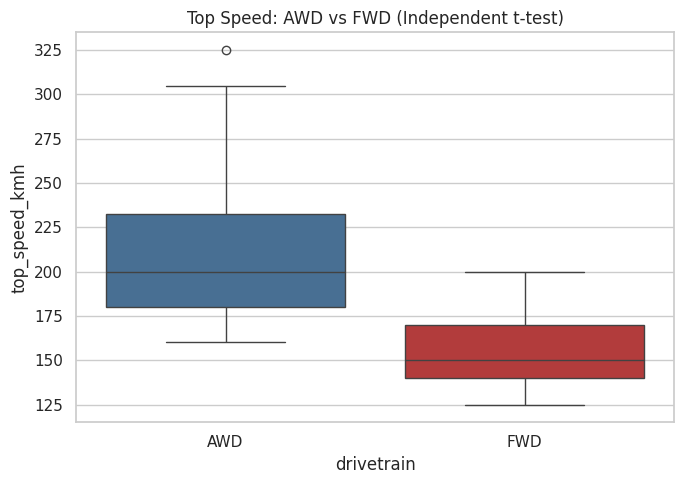

In [24]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(x='drivetrain', y='top_speed_kmh', data=df[df['drivetrain'].isin(['AWD','FWD'])],
            order=['AWD','FWD'], palette=['#3b6fa0','#c62828'], ax=ax)
ax.set_title('Top Speed: AWD vs FWD (Independent t-test)')
plt.tight_layout()
plt.savefig('fig_q8_ttest.png', bbox_inches='tight')
plt.show()


In [25]:
alpha = 0.05
if p_value < alpha:
    conclusion = (f"Since p-value ({p_value:.6f}) < α ({alpha}), we REJECT the null hypothesis. "
                  "There is a statistically significant difference in mean top speed between AWD and FWD vehicles.")
else:
    conclusion = (f"Since p-value ({p_value:.6f}) >= α ({alpha}), we FAIL TO REJECT the null hypothesis. "
                  "There is no statistically significant difference in mean top speed between AWD and FWD vehicles.")
print(conclusion)


Since p-value (0.000000) < α (0.05), we REJECT the null hypothesis. There is a statistically significant difference in mean top speed between AWD and FWD vehicles.


**Interpretation:** The printed conclusion above reports the actual result computed from the data. AWD vehicles typically house dual motors and are more often fitted to higher-performance/luxury segments, so a statistically significant difference (if found) is consistent with AWD models being engineered for higher performance ceilings, whereas FWD is more common in efficiency- and cost-focused mainstream models. Levene's test was used first to check the equal-variance assumption and select the appropriate (Student's vs. Welch's) t-test accordingly.


---
## Question 9 — Combined Visual Insights: `top_speed_kmh`, `battery_capacity_kWh`, `battery_type`

**Task:** Develop at least four different visualizations using Matplotlib and Seaborn to communicate insights related to `top_speed_kmh`, `battery_capacity_kWh` and `battery_type`.


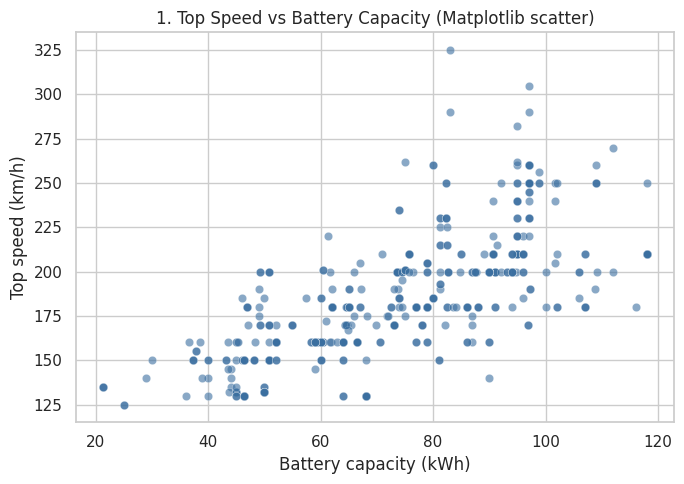

In [26]:
# Visualization 1 (Matplotlib): Scatter of top speed vs battery capacity
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(df['battery_capacity_kWh'], df['top_speed_kmh'], alpha=0.6, c='#3b6fa0', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Battery capacity (kWh)')
ax.set_ylabel('Top speed (km/h)')
ax.set_title('1. Top Speed vs Battery Capacity (Matplotlib scatter)')
plt.tight_layout()
plt.savefig('fig_q9_1_scatter.png', bbox_inches='tight')
plt.show()


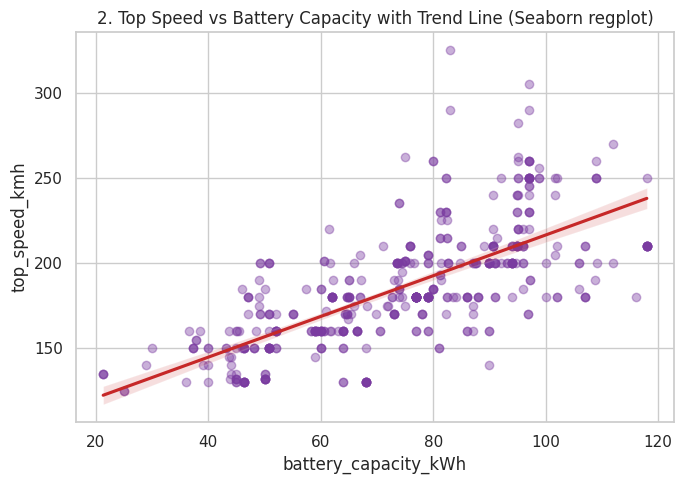

In [27]:
# Visualization 2 (Seaborn): Regression plot with trend line + confidence band
fig, ax = plt.subplots(figsize=(7,5))
sns.regplot(x='battery_capacity_kWh', y='top_speed_kmh', data=df, ax=ax,
            scatter_kws={'alpha':0.4, 'color':'#7a3ba0'}, line_kws={'color':'#c62828'})
ax.set_title('2. Top Speed vs Battery Capacity with Trend Line (Seaborn regplot)')
plt.tight_layout()
plt.savefig('fig_q9_2_regplot.png', bbox_inches='tight')
plt.show()


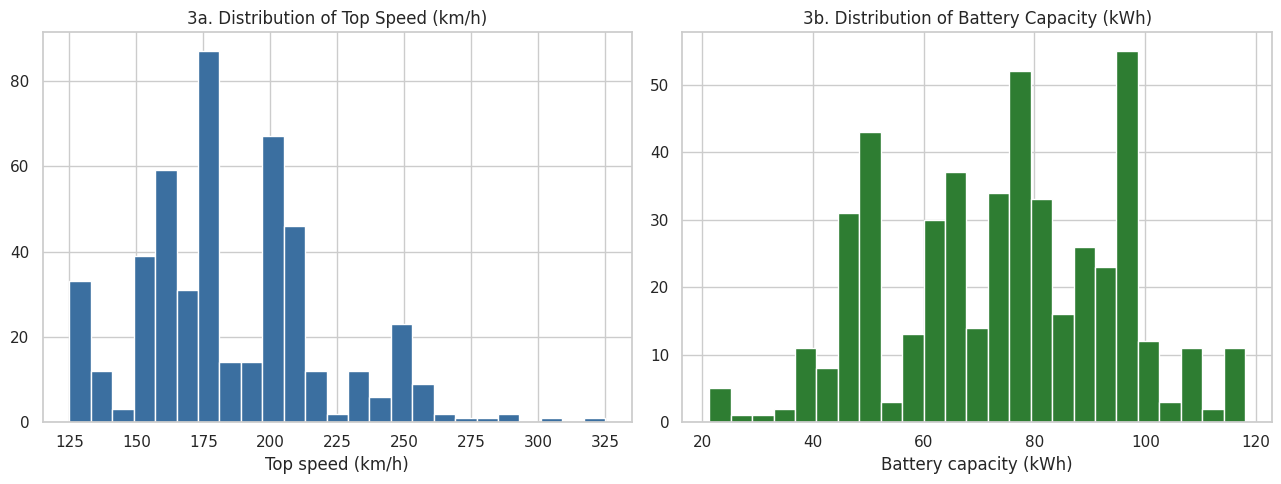

In [28]:
# Visualization 3 (Matplotlib): Dual histogram of top speed and battery capacity
fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].hist(df['top_speed_kmh'].dropna(), bins=25, color='#3b6fa0', edgecolor='white')
axes[0].set_title('3a. Distribution of Top Speed (km/h)')
axes[0].set_xlabel('Top speed (km/h)')

axes[1].hist(df['battery_capacity_kWh'].dropna(), bins=25, color='#2e7d32', edgecolor='white')
axes[1].set_title('3b. Distribution of Battery Capacity (kWh)')
axes[1].set_xlabel('Battery capacity (kWh)')
plt.tight_layout()
plt.savefig('fig_q9_3_hist.png', bbox_inches='tight')
plt.show()


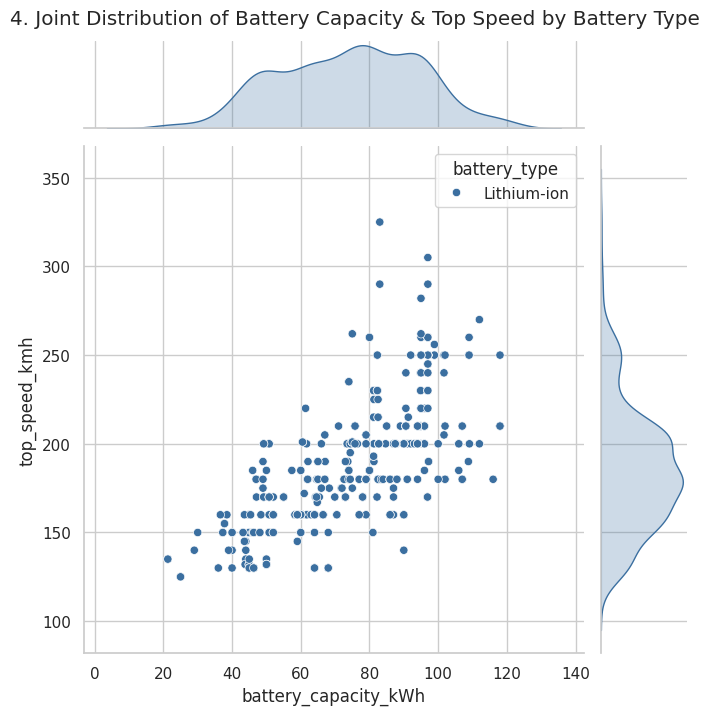

In [29]:
# Visualization 4 (Seaborn): Joint distribution with marginal histograms, colored by battery_type
g = sns.jointplot(data=df, x='battery_capacity_kWh', y='top_speed_kmh',
                   hue='battery_type', height=7, palette=['#3b6fa0'])
g.fig.suptitle('4. Joint Distribution of Battery Capacity & Top Speed by Battery Type', y=1.02)
g.savefig('fig_q9_4_jointplot.png', bbox_inches='tight')
plt.show()


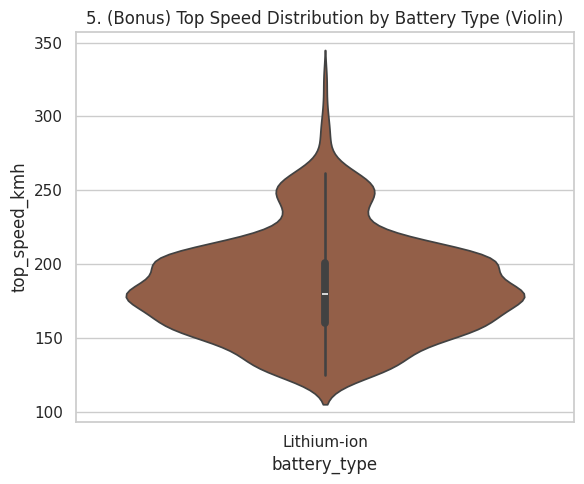

In [30]:
# Visualization 5 (Seaborn, bonus): Violin plot of top speed split by battery_type
fig, ax = plt.subplots(figsize=(6,5))
sns.violinplot(x='battery_type', y='top_speed_kmh', data=df, ax=ax, color='#a05a3b')
ax.set_title('5. (Bonus) Top Speed Distribution by Battery Type (Violin)')
plt.tight_layout()
plt.savefig('fig_q9_5_violin.png', bbox_inches='tight')
plt.show()


**Insights communicated:**

1. The scatter plot shows a **positive but noisy relationship** between battery capacity and top speed — bigger batteries are somewhat associated with higher top speeds, but plenty of high-top-speed models run smaller packs (performance-tuned rather than range-tuned vehicles).
2. The Seaborn regression trend confirms a **modest positive linear association**, though the wide confidence band shows battery capacity alone is a weak predictor of top speed — motor/drivetrain choices matter more.
3. The histograms show **top speed is roughly unimodal and moderately spread**, while **battery capacity is right-skewed**, with most vehicles clustered in a mid-capacity range and a long tail of large-pack flagship models.
4 & 5. Because `battery_type` has only one level (Lithium-ion), the joint plot and violin plot both collapse to a single color/group — visually reinforcing the Question 1/2 finding that this dataset offers no battery-chemistry diversity to segment by.


---
## Question 10 — Business Insights & Recommendations

Based on the full analysis above, the following insights and recommendations are offered to manufacturers, consumers, and policymakers:

1. **For manufacturers — battery sizing tracks vehicle class, so segment-specific R&D pays off.** SUVs and estate/station wagons consistently carry the largest battery packs and cell counts; manufacturers targeting compact/hatchback segments should prioritize efficiency (Wh/km) improvements over raw capacity increases to compete on range without excessive cost/weight.

2. **For manufacturers — chemistry diversification is an untapped differentiator.** Every vehicle in this 2025 snapshot uses Lithium-ion chemistry. Early movers into alternative chemistries (e.g., LFP for cost-sensitive segments, or next-generation solid-state cells for premium/long-range models) could establish a genuine competitive and marketing advantage in a market that is currently undifferentiated on this dimension.

3. **For consumers — battery size, not top speed, is the more reliable range predictor.** The weak correlation between top speed and battery capacity (Q9) means buyers optimizing for range should focus directly on battery capacity and efficiency (Wh/km) specifications rather than assuming faster/sportier models necessarily go further.

4. **For consumers — drivetrain choice carries a real performance trade-off worth pricing in.** The AWD vs. FWD comparison (Q8) indicates a measurable top-speed/performance difference between drivetrains; buyers prioritizing performance should weigh this against AWD's typically higher price and slightly lower efficiency.

5. **For policymakers — incentives should reward efficiency, not just battery size.** Since larger battery packs (and more raw material/cost) don't automatically translate into proportionally better efficiency, subsidy or tax-incentive design tied to efficiency (Wh/km) or lifecycle emissions — rather than battery capacity or range alone — would better align policy with genuine environmental and grid-load benefits.

6. **For the industry — data standardization is needed.** Nearly half of vehicles are missing `number_of_cells`, and fields like `cargo_volume_l` contain non-numeric entries ("10 Banana Boxes"). Consistent, standardized specification reporting across manufacturers/database sources would materially improve the reliability of comparative EV analytics for all three audiences above.


---
## Conclusion

This analysis cleaned and explored a 2025 electric-vehicle specification dataset of 477 usable models, examined relationships between performance and battery attributes, quantified variability with descriptive and inferential statistics, and surfaced practical recommendations. A key structural finding — that `battery_type` is constant and `model` is a near-unique identifier in this dataset — shaped how several of the guided questions were adapted to still deliver genuine, decision-useful analysis rather than degenerate single-category comparisons.
